In [1]:
# Librerias

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [2]:
# Importar datos

data = pd.read_csv(r'C:\Users\alejo\OneDrive\Documentos\Analítica-3\Repos\Finanzas_propio\data\datos_historicos.csv')
nuevos = pd.read_csv(r'C:\Users\alejo\OneDrive\Documentos\Analítica-3\Repos\Finanzas_propio\data\datos_nuevos_creditos.csv')

In [3]:
# Información general del dataset
print(data.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   ID                               10000 non-null  int64  
 1   CreditScore                      10000 non-null  int64  
 2   DebtRatio                        10000 non-null  float64
 3   Assets                           10000 non-null  int64  
 4   Age                              10000 non-null  int64  
 5   NumberOfDependents               10000 non-null  int64  
 6   NumberOfOpenCreditLinesAndLoans  10000 non-null  int64  
 7   MonthlyIncome                    10000 non-null  int64  
 8   NumberOfTimesPastDue             10000 non-null  int64  
 9   EmploymentLength                 10000 non-null  int64  
 10  HomeOwnership                    10000 non-null  object 
 11  Education                        10000 non-null  object 
 12  MaritalStatus      

In [4]:
# Resumen estadístico de variables numéricas
print(data.describe())

                ID   CreditScore     DebtRatio        Assets          Age  \
count  10000.00000  10000.000000  10000.000000   10000.00000  10000.00000   
mean    5000.50000    577.648800      0.499706  109870.32650     53.21540   
std     2886.89568    159.219702      0.287868   51950.50836     20.65087   
min        1.00000    300.000000      0.000035   20008.00000     18.00000   
25%     2500.75000    438.000000      0.252349   64306.50000     35.75000   
50%     5000.50000    581.000000      0.501707  110635.50000     53.00000   
75%     7500.25000    717.000000      0.744447  153852.25000     71.00000   
max    10000.00000    849.000000      0.999834  199984.00000     89.00000   

       NumberOfDependents  NumberOfOpenCreditLinesAndLoans  MonthlyIncome  \
count        10000.000000                     10000.000000   10000.000000   
mean             4.503500                         9.452900   10446.551100   
std              2.862028                         5.729211    5449.335633  

In [5]:
# Distribución de frecuencias para variables categóricas
categorical_columns = data.select_dtypes(include=['object']).columns
for col in categorical_columns:
    print(f"\n{col}:\n{data[col].value_counts()}")


HomeOwnership:
HomeOwnership
Rent        3427
Mortgage    3349
Own         3224
Name: count, dtype: int64

Education:
Education
Bachelor       2551
High School    2535
Masters        2488
PhD            2426
Name: count, dtype: int64

MaritalStatus:
MaritalStatus
Widowed     2568
Divorced    2536
Single      2482
Married     2414
Name: count, dtype: int64


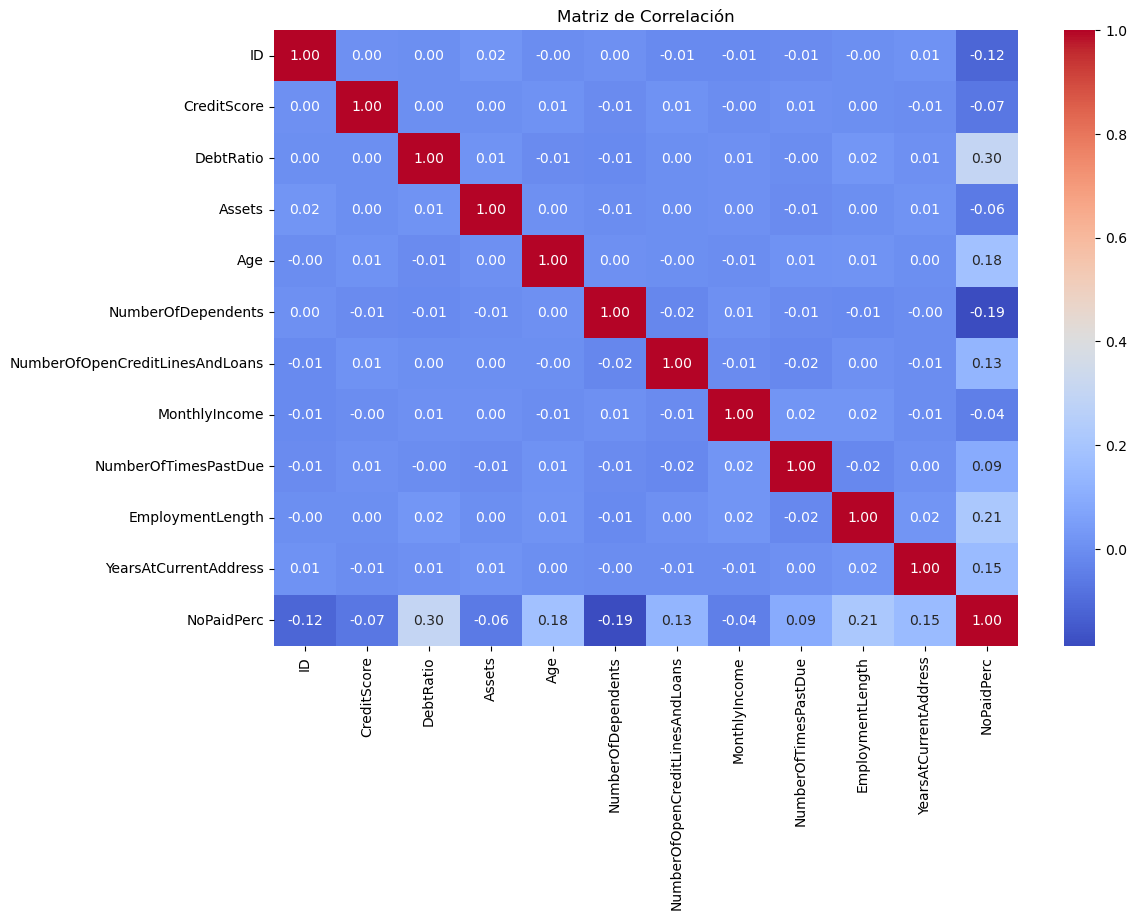

In [6]:
# Matriz de correlación entre variables numéricas
plt.figure(figsize=(12, 8))

# Seleccionar solo columnas numéricas
numeric_data = data.select_dtypes(include=['number'])

# Calcular matriz de correlación
correlation_matrix = numeric_data.corr()

# Crear un heatmap
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de Correlación")
plt.show()

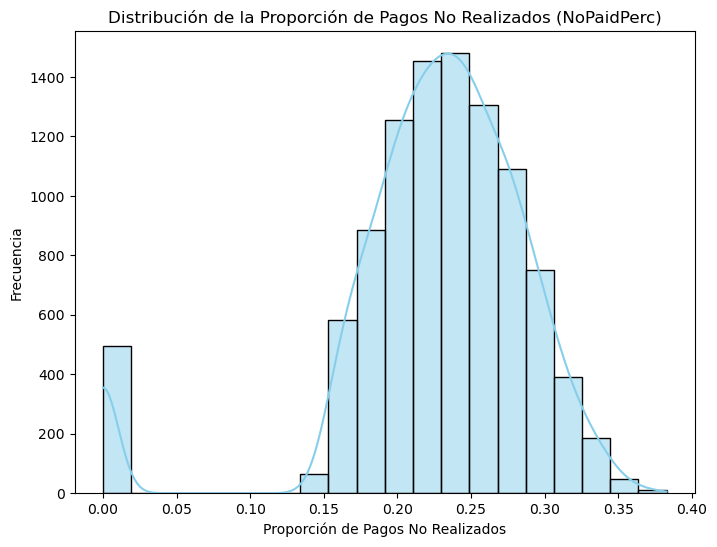

In [7]:
# Distribución de `NoPaidPerc`
plt.figure(figsize=(8, 6))
sns.histplot(data['NoPaidPerc'], bins=20, kde=True, color="skyblue")
plt.title("Distribución de la Proporción de Pagos No Realizados (NoPaidPerc)")
plt.xlabel("Proporción de Pagos No Realizados")
plt.ylabel("Frecuencia")
plt.show()

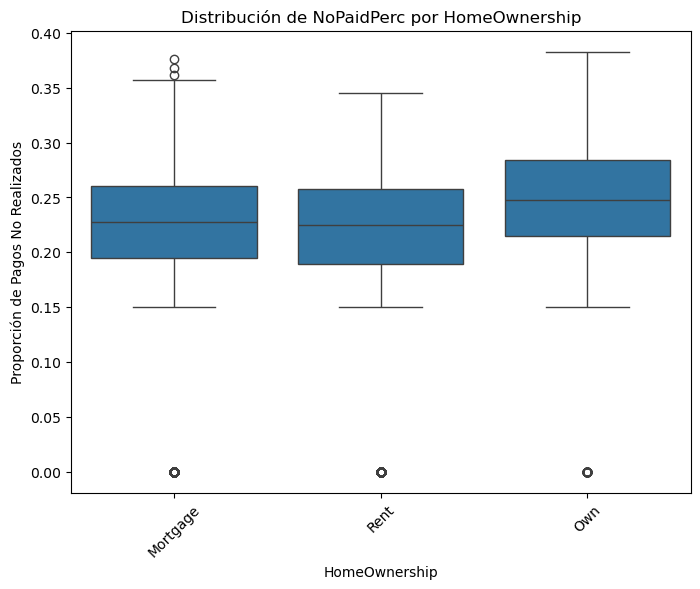

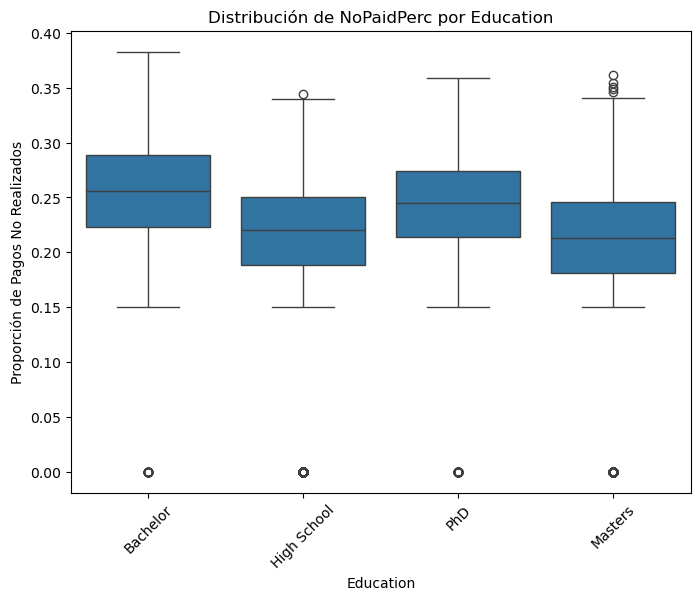

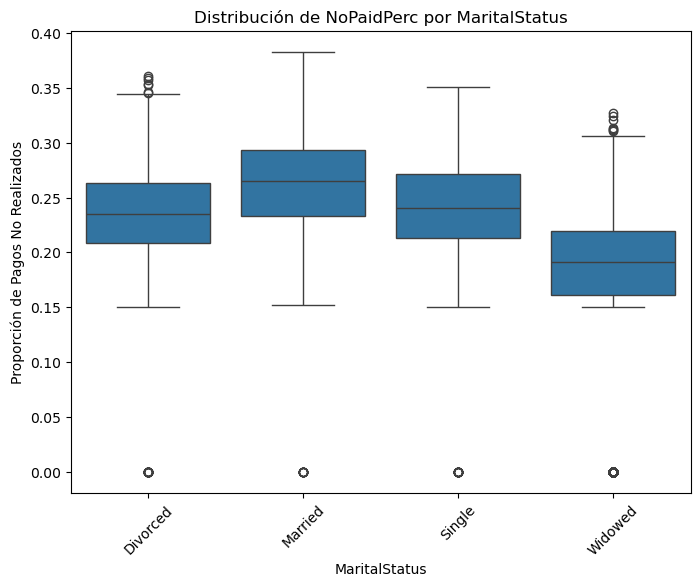

In [8]:
# Relación de `NoPaidPerc` con variables categóricas
categorical_vars = ['HomeOwnership', 'Education', 'MaritalStatus']
for var in categorical_vars:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=var, y='NoPaidPerc', data=data)
    plt.title(f"Distribución de NoPaidPerc por {var}")
    plt.xlabel(var)
    plt.ylabel("Proporción de Pagos No Realizados")
    plt.xticks(rotation=45)
    plt.show()

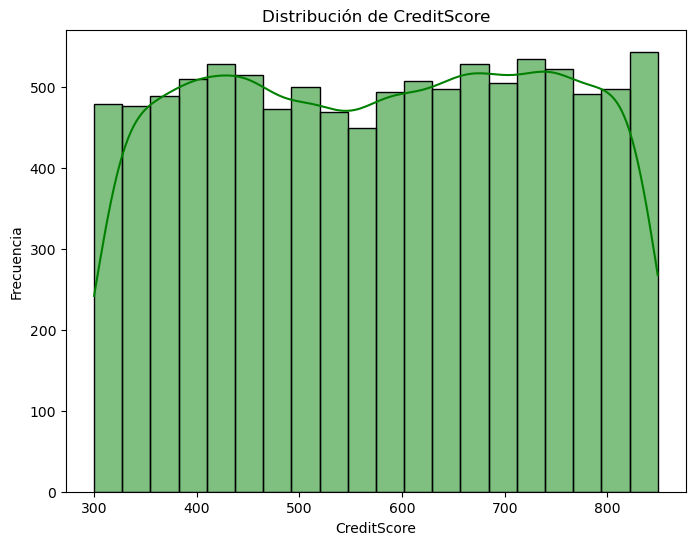

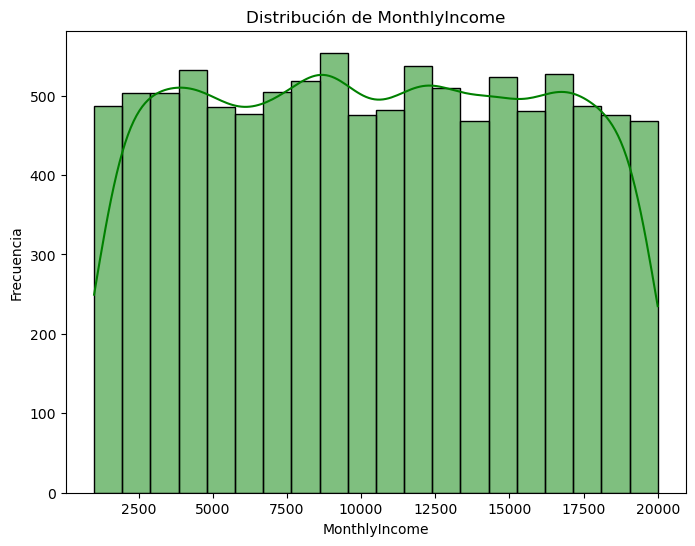

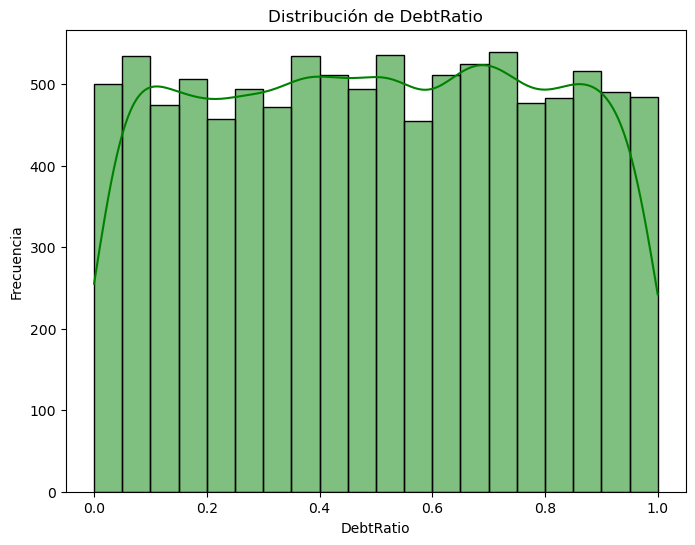

In [9]:
# Distribuciones de variables clave
key_numeric_vars = ['CreditScore', 'MonthlyIncome', 'DebtRatio']
for var in key_numeric_vars:
    plt.figure(figsize=(8, 6))
    sns.histplot(data[var], bins=20, kde=True, color="green")
    plt.title(f"Distribución de {var}")
    plt.xlabel(var)
    plt.ylabel("Frecuencia")
    plt.show()

In [10]:
# 1. Separar las variables dependientes e independientes
X = data.drop(columns=["NoPaidPerc", "ID"])  # Variables predictoras
y = data["NoPaidPerc"]  # Variable objetivo

# 2. Identificar variables categóricas y numéricas
categorical_columns = ['HomeOwnership', 'Education', 'MaritalStatus']
numerical_columns = ['CreditScore', 'DebtRatio', 'Assets', 'Age', 'NumberOfDependents', 
                     'NumberOfOpenCreditLinesAndLoans', 'MonthlyIncome', 'NumberOfTimesPastDue', 
                     'EmploymentLength', 'YearsAtCurrentAddress']

# 3. Definir el preprocesador de datos
# Pipeline para variables numéricas: (Sin escalado)
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))  # Imputación de valores nulos con la media
])

# Pipeline para variables categóricas: Imputación de valores nulos (si es necesario) y One-Hot Encoding
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Imputación de la categoría más frecuente
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  # One-Hot Encoding
])

# 4. Aplicar transformaciones a las columnas numéricas y categóricas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_columns),
        ('cat', categorical_pipeline, categorical_columns)
    ])


In [12]:
# 5. Dividir el dataset en conjunto de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Definir el pipeline del modelo
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Pipeline ya definido anteriormente
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  # Aplicar preprocesamiento
    ('regressor', RandomForestRegressor(random_state=42))  # Random Forest
])

# 7. Configurar la grilla de hiperparámetros
from sklearn.model_selection import GridSearchCV

# Definir los hiperparámetros a evaluar
param_grid = {
    'regressor__n_estimators': [100, 200, 300],  # Número de árboles en el bosque
    'regressor__max_depth': [10, 20, None],      # Profundidad máxima del árbol
    'regressor__min_samples_split': [2, 5, 10],  # Mínimo de muestras para dividir un nodo
    'regressor__min_samples_leaf': [1, 2, 4]     # Mínimo de muestras en las hojas
}

# Configurar GridSearchCV
grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    cv=5,  # Validación cruzada con 5 folds
    scoring='neg_mean_squared_error',  # Métrica de evaluación
    n_jobs=-1,  # Paralelización para acelerar el proceso
    verbose=2   # Nivel de detalle durante la ejecución
)

# 8. Entrenar la grilla de búsqueda
grid_search.fit(X_train, y_train)

# 9. Evaluar el mejor modelo
best_model = grid_search.best_estimator_  # Mejor combinación de hiperparámetros
y_pred = best_model.predict(X_test)

# Importar métricas de regresión
from sklearn.metrics import mean_squared_error, r2_score

# Evaluar el modelo usando MSE y R2
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Mostrar los resultados
print("Best Parameters:", grid_search.best_params_)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)


Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Parameters: {'regressor__max_depth': None, 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 300}
Mean Squared Error: 0.0010986614792924021
R2 Score: 0.7561947728583895


In [13]:
import joblib

# Guardar el mejor modelo en un archivo
joblib.dump(best_model, "mejor_modelo_rf.pkl")

print("Modelo guardado exitosamente.")

Modelo guardado exitosamente.


In [10]:
nuevos

,ID,CreditScore,DebtRatio,Assets,Age,NumberOfDependents,NumberOfOpenCreditLinesAndLoans,MonthlyIncome,NumberOfTimesPastDue,EmploymentLength,HomeOwnership,Education,MaritalStatus,YearsAtCurrentAddress,NewLoanApplication
0,10001,737,0.479047,34979,63,6,12,2904,8,15,Mortgage,High School,Widowed,20,37752.0
1,10002,411,0.442930,56459,28,7,4,17639,11,4,Rent,High School,Widowed,21,52917.0
2,10003,732,0.532314,76570,26,5,8,17730,7,10,Rent,High School,Widowed,10,106380.0
3,10004,710,0.295541,86752,51,8,16,7166,16,18,Mortgage,Masters,Widowed,17,35830.0
4,10005,848,0.248378,102286,29,4,8,4688,16,1,Own,High School,Widowed,26,32816.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1053,11054,603,0.257370,179888,37,0,17,19788,8,1,Mortgage,High School,Widowed,23,356184.0
1054,11055,710,0.690966,178287,48,6,8,13469,3,14,Rent,Bachelor,Widowed,14,282849.0
1055,11056,642,0.099068,195318,45,5,19,15991,0,6,Own,PhD,Single,22,319820.0
1056,11057,790,0.164651,109782,59,8,17,9726,7,17,Own,High School,Widowed,28,116712.0


In [12]:
# 1. Separar las variables dependientes e independientes
nuevos_2 = nuevos.drop(columns=["NewLoanApplication", "ID"])  # Variables predictoras

# 2. Identificar variables categóricas y numéricas
categorical_columns = ['HomeOwnership', 'Education', 'MaritalStatus']
numerical_columns = ['CreditScore', 'DebtRatio', 'Assets', 'Age', 'NumberOfDependents', 
                     'NumberOfOpenCreditLinesAndLoans', 'MonthlyIncome', 'NumberOfTimesPastDue', 
                     'EmploymentLength', 'YearsAtCurrentAddress']

# 3. Definir el preprocesador de datos
# Pipeline para variables numéricas: (Sin escalado)
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))  # Imputación de valores nulos con la media
])

# Pipeline para variables categóricas: Imputación de valores nulos (si es necesario) y One-Hot Encoding
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Imputación de la categoría más frecuente
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  # One-Hot Encoding
])

# 4. Aplicar transformaciones a las columnas numéricas y categóricas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_columns),
        ('cat', categorical_pipeline, categorical_columns)
    ])


In [13]:
import joblib
# Cargar el modelo guardado
modelo_cargado = joblib.load("mejor_modelo_rf.pkl")

# Realizar predicciones con el modelo cargado
y_nuevas_predicciones = modelo_cargado.predict(nuevos_2)

print("Predicciones realizadas con el modelo cargado.")

Predicciones realizadas con el modelo cargado.


In [14]:
y_nuevas_predicciones

array([0.14938221, 0.07050316, 0.13519252, ..., 0.18452032, 0.03451816,
       0.19275141])

In [15]:
nuevos["predict"] = y_nuevas_predicciones

In [16]:
nuevos

,ID,CreditScore,DebtRatio,Assets,Age,NumberOfDependents,NumberOfOpenCreditLinesAndLoans,MonthlyIncome,NumberOfTimesPastDue,EmploymentLength,HomeOwnership,Education,MaritalStatus,YearsAtCurrentAddress,NewLoanApplication,predict
0,10001,737,0.479047,34979,63,6,12,2904,8,15,Mortgage,High School,Widowed,20,37752.0,0.149382
1,10002,411,0.442930,56459,28,7,4,17639,11,4,Rent,High School,Widowed,21,52917.0,0.070503
2,10003,732,0.532314,76570,26,5,8,17730,7,10,Rent,High School,Widowed,10,106380.0,0.135193
3,10004,710,0.295541,86752,51,8,16,7166,16,18,Mortgage,Masters,Widowed,17,35830.0,0.106051
4,10005,848,0.248378,102286,29,4,8,4688,16,1,Own,High School,Widowed,26,32816.0,0.025085
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1053,11054,603,0.257370,179888,37,0,17,19788,8,1,Mortgage,High School,Widowed,23,356184.0,0.145679
1054,11055,710,0.690966,178287,48,6,8,13469,3,14,Rent,Bachelor,Widowed,14,282849.0,0.166869
1055,11056,642,0.099068,195318,45,5,19,15991,0,6,Own,PhD,Single,22,319820.0,0.184520
1056,11057,790,0.164651,109782,59,8,17,9726,7,17,Own,High School,Widowed,28,116712.0,0.034518


In [22]:
# Implementación de la opción 1
def calcular_interes_riesgo_1(row, factor_recuperacion=0.5):
    monto = row['NewLoanApplication']
    riesgo = row['predict']
    interes_riesgo = monto * riesgo * (1 - factor_recuperacion)
    return max(interes_riesgo / monto, 0) # Convertir a porcentaje

# Aplicar la función al dataset
nuevos['RiesgoInteres_1'] = nuevos.apply(calcular_interes_riesgo_1, axis=1)

In [23]:
nuevos

,ID,CreditScore,DebtRatio,Assets,Age,NumberOfDependents,NumberOfOpenCreditLinesAndLoans,MonthlyIncome,NumberOfTimesPastDue,EmploymentLength,HomeOwnership,Education,MaritalStatus,YearsAtCurrentAddress,NewLoanApplication,predict,RiesgoInteres_1
0,10001,737,0.479047,34979,63,6,12,2904,8,15,Mortgage,High School,Widowed,20,37752.0,0.149382,0.074691
1,10002,411,0.442930,56459,28,7,4,17639,11,4,Rent,High School,Widowed,21,52917.0,0.070503,0.035252
2,10003,732,0.532314,76570,26,5,8,17730,7,10,Rent,High School,Widowed,10,106380.0,0.135193,0.067596
3,10004,710,0.295541,86752,51,8,16,7166,16,18,Mortgage,Masters,Widowed,17,35830.0,0.106051,0.053026
4,10005,848,0.248378,102286,29,4,8,4688,16,1,Own,High School,Widowed,26,32816.0,0.025085,0.012543
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1053,11054,603,0.257370,179888,37,0,17,19788,8,1,Mortgage,High School,Widowed,23,356184.0,0.145679,0.072840
1054,11055,710,0.690966,178287,48,6,8,13469,3,14,Rent,Bachelor,Widowed,14,282849.0,0.166869,0.083435
1055,11056,642,0.099068,195318,45,5,19,15991,0,6,Own,PhD,Single,22,319820.0,0.184520,0.092260
1056,11057,790,0.164651,109782,59,8,17,9726,7,17,Own,High School,Widowed,28,116712.0,0.034518,0.017259


In [59]:
import pandas as pd

# Crear una copia para no modificar el DataFrame original
clientes = nuevos.copy()

# Definir una función para calcular la tasa adicional basada en reglas
def calcular_tasa_adicional(row):
    tasa = 0  # Base adicional es 0%
    
    # Regla para DebtRatio
    if row['DebtRatio'] < 0.3:
        tasa += 1  # 1%
    elif 0.3 <= row['DebtRatio'] <= 0.6:
        tasa += 3  # 3%
    else:
        tasa += 5  # 5%
    
    # Regla para Age
    if row['Age'] < 25:
        tasa += 2  # 2%
    elif row['Age'] > 60:
        tasa += 3  # 3%
    
    # Regla para NumberOfDependents
    if row['NumberOfDependents'] == 0:
        tasa += 0  # Sin ajuste
    elif row['NumberOfDependents'] <= 2:
        tasa += 1  # 1%
    else:
        tasa += 2  # 2%
    
    # Regla para EmploymentLength
    if row['EmploymentLength'] < 1:
        tasa += 5  # 5%
    elif 1 <= row['EmploymentLength'] <= 5:
        tasa += 2  # 2%
    
    return tasa

# Aplicar la función al DataFrame
clientes['TasaAdicional_Reglas'] = clientes.apply(calcular_tasa_adicional, axis=1)/100

clientes


,ID,CreditScore,DebtRatio,Assets,Age,NumberOfDependents,NumberOfOpenCreditLinesAndLoans,MonthlyIncome,NumberOfTimesPastDue,EmploymentLength,HomeOwnership,Education,MaritalStatus,YearsAtCurrentAddress,NewLoanApplication,predict,RiesgoInteres_1,Cluster,TasaAdicional_Reglas
0,10001,737,0.479047,34979,63,6,12,2904,8,15,Mortgage,High School,Widowed,20,37752.0,0.149382,0.074691,1,0.08
1,10002,411,0.442930,56459,28,7,4,17639,11,4,Rent,High School,Widowed,21,52917.0,0.070503,0.035252,1,0.07
2,10003,732,0.532314,76570,26,5,8,17730,7,10,Rent,High School,Widowed,10,106380.0,0.135193,0.067596,1,0.05
3,10004,710,0.295541,86752,51,8,16,7166,16,18,Mortgage,Masters,Widowed,17,35830.0,0.106051,0.053026,2,0.03
4,10005,848,0.248378,102286,29,4,8,4688,16,1,Own,High School,Widowed,26,32816.0,0.025085,0.012543,0,0.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1053,11054,603,0.257370,179888,37,0,17,19788,8,1,Mortgage,High School,Widowed,23,356184.0,0.145679,0.072840,0,0.03
1054,11055,710,0.690966,178287,48,6,8,13469,3,14,Rent,Bachelor,Widowed,14,282849.0,0.166869,0.083435,1,0.07
1055,11056,642,0.099068,195318,45,5,19,15991,0,6,Own,PhD,Single,22,319820.0,0.184520,0.092260,0,0.03
1056,11057,790,0.164651,109782,59,8,17,9726,7,17,Own,High School,Widowed,28,116712.0,0.034518,0.017259,2,0.03


In [61]:
# Definir los pesos de cada variable
w1 = 0.4  # Peso para DebtRatio
w2 = 0.2  # Peso para Age
w3 = 0.2  # Peso para NumberOfDependents
w4 = 0.2  # Peso para EmploymentLength

# Normalizar las variables (opcional, si las escalas son muy diferentes)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
clientes[['DebtRatio', 'Age', 'NumberOfDependents', 'EmploymentLength']] = scaler.fit_transform(
    clientes[['DebtRatio', 'Age', 'NumberOfDependents', 'EmploymentLength']]
)

# Calcular el puntaje compuesto
clientes['PuntajeCompuesto'] = (
    w1 * clientes['DebtRatio'] +
    w2 * clientes['Age'] +
    w3 * clientes['NumberOfDependents'] +
    w4 * clientes['EmploymentLength']
)

# Mapear el puntaje a una tasa adicional (lineal en este caso)
a = 5  # Escala del puntaje
b = 1  # Tasa base adicional
clientes['TasaAdicional_Puntaje'] = (a * clientes['PuntajeCompuesto'] + b)/100

# Revisar resultados
clientes


,ID,CreditScore,DebtRatio,Assets,Age,NumberOfDependents,NumberOfOpenCreditLinesAndLoans,MonthlyIncome,NumberOfTimesPastDue,EmploymentLength,...,Education,MaritalStatus,YearsAtCurrentAddress,NewLoanApplication,predict,RiesgoInteres_1,Cluster,TasaAdicional_Reglas,PuntajeCompuesto,TasaAdicional_Puntaje
0,10001,737,0.479732,34979,0.633803,0.666667,12,2904,8,0.517241,...,High School,Widowed,20,37752.0,0.149382,0.074691,1,0.08,0.555435,0.037772
1,10002,411,0.443554,56459,0.140845,0.777778,4,17639,11,0.137931,...,High School,Widowed,21,52917.0,0.070503,0.035252,1,0.07,0.388732,0.029437
2,10003,732,0.533091,76570,0.112676,0.555556,8,17730,7,0.344828,...,High School,Widowed,10,106380.0,0.135193,0.067596,1,0.05,0.415848,0.030792
3,10004,710,0.295912,86752,0.464789,0.888889,16,7166,16,0.620690,...,Masters,Widowed,17,35830.0,0.106051,0.053026,2,0.03,0.513238,0.035662
4,10005,848,0.248668,102286,0.154930,0.444444,8,4688,16,0.034483,...,High School,Widowed,26,32816.0,0.025085,0.012543,0,0.05,0.226239,0.021312
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1053,11054,603,0.257676,179888,0.267606,0.000000,17,19788,8,0.034483,...,High School,Widowed,23,356184.0,0.145679,0.072840,0,0.03,0.163488,0.018174
1054,11055,710,0.692014,178287,0.422535,0.666667,8,13469,3,0.482759,...,Bachelor,Widowed,14,282849.0,0.166869,0.083435,1,0.07,0.591198,0.039560
1055,11056,642,0.099103,195318,0.380282,0.555556,19,15991,0,0.206897,...,PhD,Single,22,319820.0,0.184520,0.092260,0,0.03,0.268188,0.023409
1056,11057,790,0.164798,109782,0.577465,0.888889,17,9726,7,0.586207,...,High School,Widowed,28,116712.0,0.034518,0.017259,2,0.03,0.476431,0.033822
